In [1]:
import torch
import os
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split

In [43]:
'''
TODO:
    1. Dividir dataset en train y test
    2. Código para normalizar las imágenes (a 224x224)
'''

'\nTODO:\n    1. Dividir dataset en train y test\n    2. Código para normalizar las imágenes (a 224x224)\n'

In [9]:
# --- CLASE CNN CORREGIDA ---
class CNN(nn.Module):
    # Valores por defecto corregidos: in_channels=3, num_classes=3
    def __init__(self, in_channels=3, num_classes=3):
        super(CNN, self).__init__()

        # --- Capas Convolucionales ---
        # Entrada: (3 x 224 x 224)
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, stride=1, padding=1)
        # Salida: (32 x 224 x 224)
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        # Salida: (64 x 224 x 224)
        
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        # Salida: (128 x 224 x 224)

        # --- TODO: Capa extra añadida ---
        # Esta capa no cambia el tamaño (128 canales de entrada, 128 de salida)
        self.conv_extra = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1)
        # Salida: (128 x 224 x 224)

        # --- Pooling (definido UNA SOLA VEZ) ---
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # --- Capas Totalmente Conectadas (Clasificador) ---
        # El tamaño de entrada se calcula así:
        # Imagen inicial: 224x224
        # Después de pool 1: 112x112
        # Después de pool 2: 56x56
        # Después de pool 3: 28x28
        # Tamaño final aplanado: 128 canales * 28 * 28
        self.fc1 = nn.Linear(128 * 28 * 28, 128)

        # --- M2 ---
        #self.dropout = nn.Dropout(p=0.5) # Apaga el 50% de las neuronas
        self.fc2 = nn.Linear(128, num_classes) # num_classes será 3

    def forward(self, x):
        # Bloque 1
        x = F.relu(self.conv1(x))
        x = self.pool(x)  # Tamaño: (32 x 112 x 112)

        # Bloque 2
        x = F.relu(self.conv2(x))
        x = self.pool(x)  # Tamaño: (64 x 56 x 56)

        # Bloque 3 + Capa extra
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv_extra(x)) # Nueva capa
        x = self.pool(x)  # Tamaño: (128 x 28 x 28)

        # Aplanar para el clasificador
        x = x.reshape(x.shape[0], -1) 

        # Clasificador
        x = F.relu(self.fc1(x))
        #x = self.dropout(x) # Aplicar dropout antes de la última capa para M2
        x = self.fc2(x) # Salida final (logits)

        return x

In [10]:
# Importa esto si no lo tienes
from torchvision import transforms as T

# --- Definir la clase Dataset ---
class ImageDataset(Dataset):
    """
    Dataset personalizado para cargar imágenes desde una lista de rutas.
    """
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        # Devuelve el número total de muestras
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        
        # Abrimos la imagen y la convertimos a 'RGB' (3 canales)
        # Esto es vital para que coincida con in_channels=3
        image = Image.open(img_path).convert('RGB') 
        
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)
            
        return image, label

# --- Definir Transformaciones (TODO 2) ---
# Redimensionamos a 224x224 (para que coincida con el cálculo de fc1)
# y normalizamos.
# NOTA: Usamos la media y std de ImageNet. Es una buena práctica
# incluso para modelos desde cero, y será NECESARIO
# para el Transfer Learning más adelante.


##########   MODELO 2  ###########

#data_transform = T.Compose([
#    T.Resize((224, 224)),
#    T.ToTensor(),
#    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
#])

##########   MODELO 3  ###########
# [BLOQUE A - REEMPLAZO PARA MODELO 3]

# --- Definir Transformaciones (con Aumentación) ---

# 1. Transformación para Validación (sin aumentación)
# (Es la misma que tenías antes)
val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Transformación para Entrenamiento (CON aumentación)
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5), # 50% de probabilidad de volteo horizontal
    T.RandomRotation(15),          # Giro aleatorio entre -15 y +15 grados
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# --- Cargar y Dividir Datos (TODO 1) ---

# 1. Definir la ruta y encontrar clases
data_dir = Path('Breast-Cancer-Dataset')
classes = [d.name for d in data_dir.iterdir() if d.is_dir()]
label_map = {name: i for i, name in enumerate(classes)}
num_classes = len(classes)

print(f"Clases encontradas: {label_map}") # Debería ser {'benign': 0, 'malignant': 1, 'normal': 2}

# 2. Recolectar todas las imágenes y etiquetas
file_paths = []
labels = []
for class_name, label_idx in label_map.items():
    class_dir = data_dir / class_name
    # Busca todos los tipos de imagen comunes (png, jpg, jpeg)
    for img_path in class_dir.glob('*.[jp][pn]g'): 
        file_paths.append(str(img_path))
        labels.append(label_idx)

print(f"Total de imágenes encontradas: {len(file_paths)}")

# 3. Dividir en entrenamiento (80%) y validación (20%)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, 
    labels, 
    test_size=0.2,        # 20% para validación
    random_state=42,      # Para resultados reproducibles
    stratify=labels       # Asegura proporción de clases en train/val
)

######### MODELO 2 ##########
# 4. Crear los Datasets
#train_dataset = ImageDataset(train_paths, train_labels, transform=data_transform)
#val_dataset = ImageDataset(val_paths, val_labels, transform=data_transform)

# 5. Crear los DataLoaders
#BATCH_SIZE = 32 # Puedes ajustar este hiperparámetro
#train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
#val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

######### MODELO 3 ##########
# [BLOQUE B - REEMPLAZO PARA MODELO 3]

# 4. Crear los Datasets
# ¡Aquí está el cambio! Pasamos el transformador correcto a cada uno.
train_dataset = ImageDataset(train_paths, train_labels, transform=train_transform)
val_dataset = ImageDataset(val_paths, val_labels, transform=val_transform)

# 5. Crear los DataLoaders (esto no cambia)
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Imágenes de entreno: {len(train_dataset)}")
print(f"Imágenes de validación: {len(val_dataset)}")


Clases encontradas: {'benign': 0, 'malignant': 1, 'normal': 2}
Total de imágenes encontradas: 780
Imágenes de entreno: 624
Imágenes de validación: 156


In [11]:
# --- Configuración del dispositivo ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

# --- Instanciar el Modelo 1 (Base) ---
# Usamos los parámetros correctos que encontramos
model = CNN(in_channels=3, num_classes=num_classes).to(device)

# --- Hiperparámetros del Modelo 1 ---
learning_rate = 0.001
NUM_EPOCHS = 25 # Empezamos con 25, puedes subirlo o bajarlo

# --- Definir la función de pérdida y el optimizador ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# --- Historial para las gráficas ---
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

# --- Bucle Principal de Entrenamiento ---
for epoch in range(NUM_EPOCHS):
    
    # --- Fase de Entrenamiento ---
    model.train() # Poner modelo en modo entrenamiento
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    # tqdm es para la barra de progreso
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]'):
        # Mover datos al dispositivo (GPU/CPU)
        images, labels = images.to(device), labels.to(device)
        
        # 1. Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 2. Backward pass y optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Calcular métricas
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)

    # --- Fase de Validación ---
    model.eval() # Poner modelo en modo evaluación
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # No calcular gradientes
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Val]'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = 100 * correct_val / total_val
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], '
          f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, '
          f'Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')

print('Entrenamiento finalizado.')

Usando dispositivo: cpu


Epoch 1/25 [Val]: 100%|██████████| 5/5 [00:06<00:00,  1.22s/it]


Epoch [1/25], Train Loss: 1.0391, Train Acc: 53.69%, Val Loss: 0.9804, Val Acc: 55.77%


Epoch 2/25 [Val]: 100%|██████████| 5/5 [00:06<00:00,  1.21s/it]


Epoch [2/25], Train Loss: 0.9560, Train Acc: 57.21%, Val Loss: 0.8931, Val Acc: 64.74%


...

Epoch [23/25], Train Loss: 0.3308, Train Acc: 85.58%, Val Loss: 0.8018, Val Acc: 75.00%


Epoch 24/25 [Val]: 100%|██████████| 5/5 [00:06<00:00,  1.21s/it]


Epoch [24/25], Train Loss: 0.2609, Train Acc: 89.74%, Val Loss: 1.1670, Val Acc: 76.92%


Epoch 25/25 [Val]: 100%|██████████| 5/5 [00:06<00:00,  1.22s/it]

Epoch [25/25], Train Loss: 0.2466, Train Acc: 91.51%, Val Loss: 1.0298, Val Acc: 76.92%
Entrenamiento finalizado.


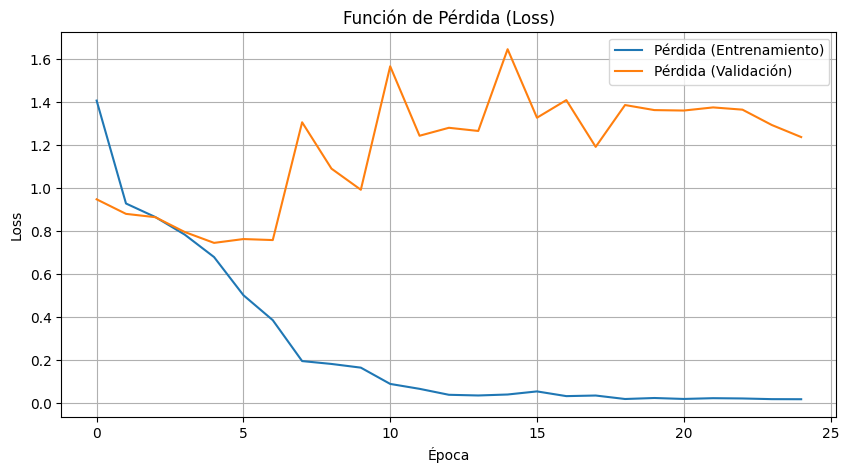

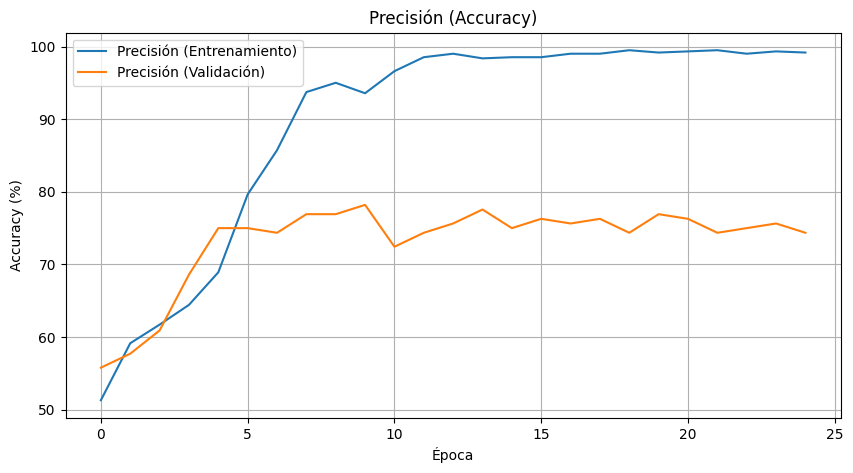

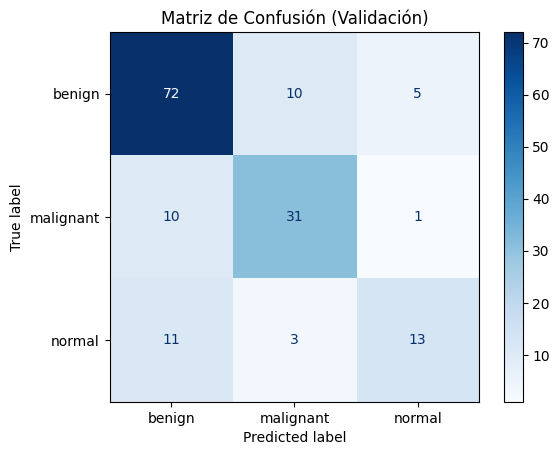

: 

In [ ]:
# Importa esto si no lo tienes
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Gráfica de Pérdida (Loss) ---
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Pérdida (Entrenamiento)')
plt.plot(history['val_loss'], label='Pérdida (Validación)')
plt.title('Función de Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Gráfica de Precisión (Accuracy) ---
plt.figure(figsize=(10, 5))
plt.plot(history['train_acc'], label='Precisión (Entrenamiento)')
plt.plot(history['val_acc'], label='Precisión (Validación)')
plt.title('Precisión (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


# --- Matriz de Confusión ---
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calcula la matriz
cm = confusion_matrix(all_labels, all_preds)

# Muestra la matriz (usando los nombres de las clases)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Validación)')
plt.show()

In [12]:
# --- PASO 5: IMPLEMENTAR TRANSFER LEARNING (Modelo 5) ---

import torchvision.models as models

print("--- Configurando Modelo 5: Transfer Learning (ResNet18) ---")

# --- 1. Cargar el ResNet18 pre-entrenado ---
# pretrained=True descarga los pesos aprendidos en ImageNet
model_tl = models.resnet18(pretrained=True)

# --- 2. Congelar todos los pesos del modelo ---
# No queremos re-entrenar el modelo, solo la capa final.
print("Congelando todas las capas del modelo...")
for param in model_tl.parameters():
    param.requires_grad = False

# --- 3. Reemplazar la última capa (el "Clasificador") ---
# ResNet18 fue entrenado para 1000 clases (ImageNet).
# Lo reemplazamos por una nueva capa para nuestras 'num_classes' (que es 3).

# Obtenemos el número de "neuronas" de entrada a la última capa
num_features = model_tl.fc.in_features 
print(f"Número de features de entrada a la última capa: {num_features}") # (Suele ser 512)

# Creamos nuestra nueva capa.
# Esta nueva capa SÍ tendrá requires_grad=True (la única que entrenará)
model_tl.fc = nn.Linear(num_features, num_classes)

# --- 4. Mover el modelo al dispositivo ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_tl = model_tl.to(device)

print("¡Modelo ResNet18 listo para Transfer Learning!")

--- Configurando Modelo 5: Transfer Learning (ResNet18) ---


c:\Users\djisj\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\djisj\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\djisj/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 30.3MB/s]


Congelando todas las capas del modelo...
Número de features de entrada a la última capa: 512
¡Modelo ResNet18 listo para Transfer Learning!


In [13]:
# --- Configuración del Entrenamiento para el Modelo 5 ---

# --- Instanciar el Modelo 5 ---
model = model_tl 

# --- Hiperparámetros ---
learning_rate = 0.001
NUM_EPOCHS = 25 # 25 épocas deberían ser suficientes

# --- Definir la función de pérdida ---
criterion = nn.CrossEntropyLoss()

# --- ¡¡¡CAMBIO CRÍTICO: EL OPTIMIZADOR!!! ---
#
# Solo le pasamos al optimizador los parámetros
# de la capa que SÍ queremos entrenar (model.fc).
#
optimizer = optim.Adam(model.fc.parameters(), lr=learning_rate)

# --- Historial para las gráficas ---
# (Reseteamos el historial para este nuevo modelo)
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

print("Optimizador configurado. Listo para entrenar la capa final.")

Optimizador configurado. Listo para entrenar la capa final.


In [14]:
# --- Bucle Principal de Entrenamiento ---
# (Esta celda usará automáticamente el 'model' y 'optimizer' que definimos antes)

print("Iniciando entrenamiento del Modelo 5 (Transfer Learning)...")

for epoch in range(NUM_EPOCHS):
    
    # --- Fase de Entrenamiento ---
    model.train() # Poner modelo en modo entrenamiento
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]'):
        images, labels = images.to(device), labels.to(device)
        
        # 1. Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 2. Backward pass y optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)

    # --- Fase de Validación ---
    model.eval() # Poner modelo en modo evaluación
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # No calcular gradientes
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Val]'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = 100 * correct_val / total_val
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], '
          f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, '
          f'Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')

print('Entrenamiento finalizado.')

Iniciando entrenamiento del Modelo 5 (Transfer Learning)...


Epoch 1/25 [Val]: 100%|██████████| 5/5 [00:07<00:00,  1.54s/it]


Epoch [1/25], Train Loss: 1.0707, Train Acc: 49.36%, Val Loss: 1.1830, Val Acc: 51.28%


Epoch 2/25 [Val]: 100%|██████████| 5/5 [00:07<00:00,  1.53s/it]


Epoch [2/25], Train Loss: 0.9048, Train Acc: 59.29%, Val Loss: 0.9060, Val Acc: 56.41%


...

Epoch [23/25], Train Loss: 0.5785, Train Acc: 75.64%, Val Loss: 0.5785, Val Acc: 77.56%


Epoch 24/25 [Val]: 100%|██████████| 5/5 [00:07<00:00,  1.54s/it]


Epoch [24/25], Train Loss: 0.5810, Train Acc: 76.60%, Val Loss: 0.6023, Val Acc: 75.00%


Epoch 25/25 [Val]: 100%|██████████| 5/5 [00:07<00:00,  1.54s/it]

Epoch [25/25], Train Loss: 0.5826, Train Acc: 74.68%, Val Loss: 0.5904, Val Acc: 74.36%
Entrenamiento finalizado.
